# Two-layer testing

This notebook tests the backend setup for a two-layer system with constant
extinction coefficient and varying single-scattering albedo.

In [1]:
# Documentation-specific setup, hidden from notebook output

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import seaborn as sns

sns.set_theme(style="ticks")

In [2]:
import eradiate
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from eradiate.contexts import KernelContext
from eradiate.experiments import AtmosphereExperiment
from eradiate.radprops import ArrayRadProfile, ZGrid
from eradiate.units import unit_registry as ureg

import eradiate_disort as ed
from eradiate_disort.util import disort_reshape_pplane

eradiate.set_mode("mono")

# Experiment parameters
SZA = 30.0
ZENITHS = np.arange(-75.0, 76.0, 1.0)
SPP = 1_000

In [3]:
# Dev-specific setup, hidden from notebook output

from eradiate_disort.testing import TestMode

plt = TestMode.plt()
SPP = TestMode.spp(tutorial=1_000, test=10_000)

## Radiative profile

The atmosphere is described by a custom radiative profile with constant total
extinction and a single-scattering albedo that steps at 50 km. The absorption
and scattering coefficients are built explicitly below.

In [4]:
zgrid = ZGrid(np.linspace(0, 100e3, 11) * ureg.m)
sigma_ref = 0.5 / zgrid.total_height  # extinction for a total optical thickness of 0.5


def sigma_step(value_a, value_b, h, zgrid):
    """Piecewise-constant vertical profile stepping from ``value_b`` (below ``h``)
    to ``value_a`` (above ``h``)."""
    z = zgrid.levels
    mask = ~(z < h)
    values = np.zeros_like(z)
    values[mask] = value_a.m_as("m^-1")
    values[~mask] = value_b.m_as("m^-1")
    return xr.DataArray(
        np.full_like(z.m_as("m"), values).reshape((1, -1)),
        dims=("w", "z"),
        coords={
            "w": ("w", [550.0], {"units": "nm"}),
            "z": ("z", z.m_as("m"), {"units": "m"}),
        },
        attrs={"units": "1/m"},
    )


sigma_a_profile = sigma_step(sigma_ref, sigma_ref / 2, 50 * ureg.km, zgrid)
sigma_s_profile = sigma_step(sigma_ref / 2, sigma_ref, 50 * ureg.km, zgrid)

Text(0.5, 0, 'm')

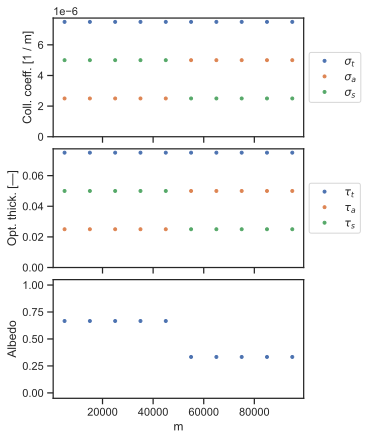

In [5]:
# Inspect the resulting collision coefficients and optical thickness
exp = AtmosphereExperiment(
    geometry={
        "type": "plane_parallel",
        "toa_altitude": 100.0 * ureg.km,
        "zgrid": zgrid,
    },
    surface={"type": "lambertian", "reflectance": 0.0},
    atmosphere={
        "type": "molecular",
        "has_scattering": True,
        "has_absorption": True,
        "thermoprops": None,
        "radprops_profile": ArrayRadProfile(
            sigma_a=sigma_a_profile,
            sigma_s=sigma_s_profile,
            has_absorption=True,
            has_scattering=True,
        ),
    },
    illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
    measures={
        "type": "mdistant",
        "construct": "hplane",
        "azimuth": 0.0,
        "zeniths": ZENITHS,
    },
)

ctx = KernelContext()
radprops = exp.atmosphere.eval_radprops(ctx.si, optional_fields=True)
h = zgrid.layer_height.m_as("m")
tau_a = np.atleast_1d(radprops["sigma_a"] * h)
tau_s = np.atleast_1d(radprops["sigma_s"] * h)
tau_t = np.atleast_1d(radprops["sigma_t"] * h)

fig, axs = plt.subplots(3, 1, layout="constrained", figsize=(5, 6), sharex=True)

ax = axs[0]
with plt.rc_context({"lines.linestyle": "", "lines.marker": "."}):
    ax.plot(radprops["z_layer"], radprops["sigma_t"], label="$\\sigma_t$")
    ax.plot(radprops["z_layer"], radprops["sigma_a"], label="$\\sigma_a$")
    ax.plot(radprops["z_layer"], radprops["sigma_s"], label="$\\sigma_s$")

ax.set_ylabel(f"Coll. coeff. [{radprops['sigma_t'].attrs['units']}]")
ax.set_ylim(0, None)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

ax = axs[1]
with plt.rc_context({"lines.linestyle": "", "lines.marker": "."}):
    ax.plot(radprops["z_layer"], tau_t, label="$\\tau_t$")
    ax.plot(radprops["z_layer"], tau_a, label="$\\tau_a$")
    ax.plot(radprops["z_layer"], tau_s, label="$\\tau_s$")

ax.set_ylabel("Opt. thick. [—]")
ax.set_ylim(0, None)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

ax = axs[2]
with plt.rc_context({"lines.linestyle": "", "lines.marker": "."}):
    ax.plot(radprops["z_layer"], radprops["albedo"])
ax.set_ylabel("Albedo")
ax.set_ylim(-0.05, 1.05)

ax.set_xlabel(radprops["z_layer"].attrs["units"])

## Backend comparison

In [6]:
results = {}
CASES = {
    "rayleigh": {
        "has_absorption": False,
        "has_scattering": True,
        "surface_reflectance": 0.0,
    },
    "absorption": {
        "has_absorption": True,
        "has_scattering": False,
        "surface_reflectance": 1.0,
    },
    "full_black": {
        "has_absorption": True,
        "has_scattering": True,
        "surface_reflectance": 0.0,
    },
    "full_white": {
        "has_absorption": True,
        "has_scattering": True,
        "surface_reflectance": 1.0,
    },
}

for case_id, kwargs in CASES.items():
    print(f"Processing case {case_id!r}")
    has_absorption = kwargs["has_absorption"]
    has_scattering = kwargs["has_scattering"]
    surface_reflectance = kwargs["surface_reflectance"]

    # Mitsuba backend
    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 100.0 * ureg.km,
            "zgrid": zgrid,
        },
        surface={"type": "lambertian", "reflectance": surface_reflectance},
        atmosphere={
            "type": "molecular",
            "has_scattering": has_scattering,
            "has_absorption": has_absorption,
            "thermoprops": None,
            "radprops_profile": ArrayRadProfile(
                sigma_a=sigma_a_profile,
                sigma_s=sigma_s_profile,
                has_absorption=has_absorption,
                has_scattering=has_scattering,
            ),
        },
        illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
        measures={
            "type": "mdistant",
            "construct": "hplane",
            "azimuth": 0.0,
            "zeniths": ZENITHS,
        },
    )
    mitsuba = eradiate.run(exp, spp=SPP)["radiance"].squeeze()

    # DISORT backend
    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 100.0 * ureg.km,
            "zgrid": zgrid,
        },
        surface={"type": "lambertian", "reflectance": surface_reflectance},
        atmosphere={
            "type": "molecular",
            "has_scattering": has_scattering,
            "has_absorption": has_absorption,
            "thermoprops": None,
            "radprops_profile": ArrayRadProfile(
                sigma_a=sigma_a_profile,
                sigma_s=sigma_s_profile,
                has_absorption=has_absorption,
                has_scattering=has_scattering,
            ),
        },
        illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
        measures={
            "type": "disort",
            "construct": "hplane",
            "azimuth": 0.0,
            "zeniths": ZENITHS,
        },
    )
    disort = disort_reshape_pplane(ed.DisortBackend().run(exp).sel(z=1e5))

    results[case_id] = {"mitsuba": mitsuba, "disort": disort}

Processing case 'rayleigh'
Processing case 'absorption'


Processing case 'full_black'
Processing case 'full_white'


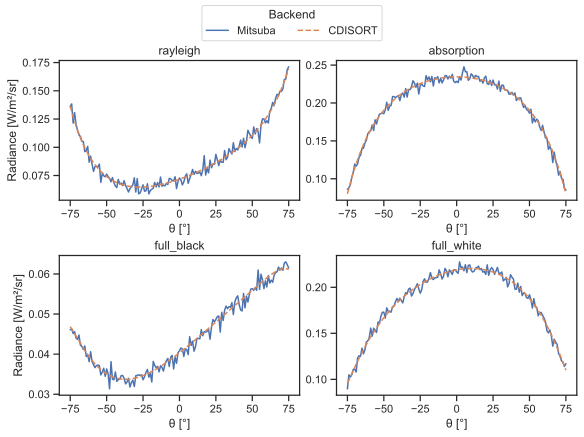

In [7]:
ncases = len(CASES)
ncols = 2
nrows = ncases // ncols + min(ncases % ncols, 1)

fig, axs = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), layout="constrained", squeeze=False
)

for i, case_id in enumerate(CASES.keys()):
    icol = i % ncols
    ax = axs.ravel()[i]
    result = results[case_id]

    ax.plot(
        result["mitsuba"]["vza"], result["mitsuba"], label="Mitsuba" if i == 0 else None
    )
    ax.plot(
        result["disort"]["vza"],
        result["disort"],
        label="CDISORT" if i == 0 else None,
        ls="--",
    )

    ax.set_title(case_id)
    ax.set_xlabel("θ [°]")
    if icol == 0:
        ax.set_ylabel("Radiance [W/m²/sr]")

else:
    while (i := i + 1) < axs.size:
        ax = axs.ravel()[i]
        ax.set_axis_off()

fig.legend(title="Backend", ncol=2, loc="outside upper center")

plt.show()